In [1]:
# --- import ----
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.semi_supervised import LabelPropagation, SelfTrainingClassifier
from sklearn.metrics import accuracy_score
from matplotlib.colors import ListedColormap

In [2]:
# 1) Create dataset
X, y = make_moons(n_samples=500, noise=0.12, random_state=0)
X_trainval, X_test, y_trainval, y_test = train_test_split(X, y, test_size=0.2, random_state=1, stratify=y)

In [3]:
# 2) Make labeled / unlabeled split (very few labeled)
rng = np.random.RandomState(2)
n_total_train = len(X_trainval)
n_labeled = 10  # small number of labeled examples
indices = np.arange(n_total_train)
rng.shuffle(indices)
labeled_idx = indices[:n_labeled]
unlabeled_idx = indices[n_labeled:]

y_train_semi = np.copy(y_trainval)
y_train_semi[unlabeled_idx] = -1  # -1 marks unlabeled points for sklearn's semi-supervised API

# For visualization: we will plot the train points, marking labeled vs unlabeled
labeled_mask = np.zeros(n_total_train, dtype=bool)
labeled_mask[labeled_idx] = True

In [4]:
# 3) Supervised baseline (train only on labeled subset)
clf_sup = LogisticRegression().fit(X_trainval[labeled_mask], y_trainval[labeled_mask])
y_pred_sup = clf_sup.predict(X_test)
acc_sup = accuracy_score(y_test, y_pred_sup)

In [5]:
# 4) Label Propagation
lp = LabelPropagation(kernel='rbf', gamma=20, max_iter=1000)
lp.fit(X_trainval, y_train_semi)
y_pred_lp = lp.predict(X_test)
acc_lp = accuracy_score(y_test, y_pred_lp)


In [9]:
# 5) Self-training (pseudo-labeling)
base = LogisticRegression()
self_train = SelfTrainingClassifier(base, threshold=0.9)  # only add pseudo-labels with high confidence
self_train.fit(X_trainval, y_train_semi)
y_pred_self = self_train.predict(X_test)
acc_self = accuracy_score(y_test, y_pred_self)

print("Test accuracy (supervised on few labels): {:.3f}".format(acc_sup))
print("Test accuracy (LabelPropagation): {:.3f}".format(acc_lp))
print("Test accuracy (Self-training): {:.3f}".format(acc_self))


Test accuracy (supervised on few labels): 0.790
Test accuracy (LabelPropagation): 0.980
Test accuracy (Self-training): 0.500


In [7]:
# 6) Plot decision boundaries
def plot_decision_boundary(clf, X, y_true, title, labeled_idx=None):
    cmap = ListedColormap(['#FFAAAA', '#AAAAFF'])
    h = .02
    x_min, x_max = X[:, 0].min() - .5, X[:, 0].max() + .5
    y_min, y_max = X[:, 1].min() - .5, X[:, 1].max() + .5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3, cmap=cmap)
    # plot training points
    plt.scatter(X[:, 0], X[:, 1], c=y_true, cmap=ListedColormap(['#FF0000', '#0000FF']), s=20, edgecolor='k')
    # highlight labeled points
    if labeled_idx is not None:
        plt.scatter(X[labeled_idx, 0], X[labeled_idx, 1], facecolors='none', edgecolors='k', s=80, linewidths=1.5, label='labeled')
    plt.title(title)
    plt.xlim(x_min, x_max)
    plt.ylim(y_min, y_max)


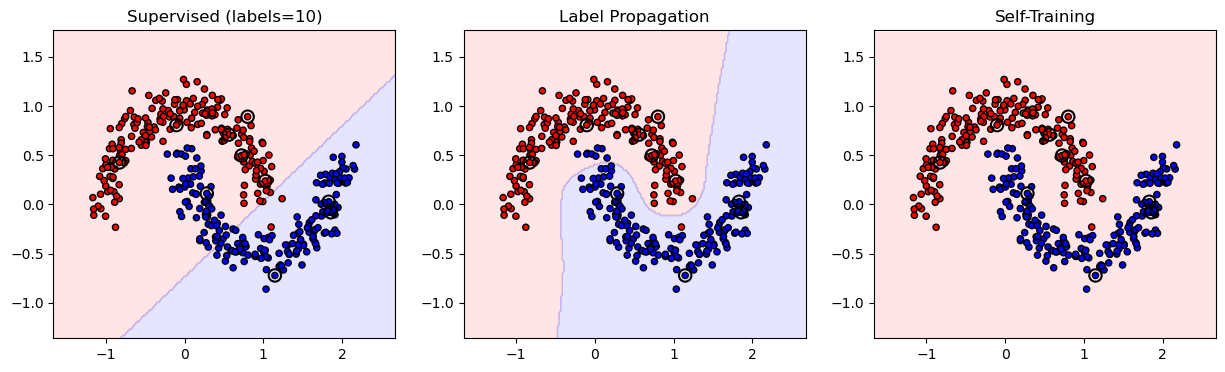

In [8]:
# Plot all three decision boundaries
plt.figure(figsize=(15,4))
plt.subplot(1,3,1)
plot_decision_boundary(clf_sup, X_trainval, y_trainval, f"Supervised (labels={n_labeled})", labeled_idx=labeled_idx)
plt.subplot(1,3,2)
plot_decision_boundary(lp, X_trainval, y_trainval, "Label Propagation", labeled_idx=labeled_idx)
plt.subplot(1,3,3)
plot_decision_boundary(self_train, X_trainval, y_trainval, "Self-Training", labeled_idx=labeled_idx)
plt.show()